In [2]:
import os

train_data_path = "train"
validation_data_path = "valid"

os.makedirs('model', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('faces/with_mask', exist_ok=True)
os.makedirs('faces/without_mask', exist_ok=True)
os.makedirs('faces', exist_ok=True)

In [3]:
import matplotlib.pyplot as plt

def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

training_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ✅ FIX 2: class_mode='categorical' use karo (2 classes hain - mask / no mask)
training_data = training_datagen.flow_from_directory(
    train_data_path,
    target_size=(200, 200),
    batch_size=128,
    class_mode='categorical'  # ✅ 'binary' se 'categorical' kiya
)

Found 900 images belonging to 2 classes.


In [5]:
print("Class Indices:", training_data.class_indices)

Class Indices: {'with_mask': 0, 'without_mask': 1}


In [ ]:
valid_datagen = ImageDataGenerator(rescale=1./255)

valid_data = valid_datagen.flow_from_directory(
    validation_data_path,
    target_size=(200, 200),
    batch_size=128,
    class_mode='categorical'  # ✅ fix
)

Found 468 images belonging to 2 classes.


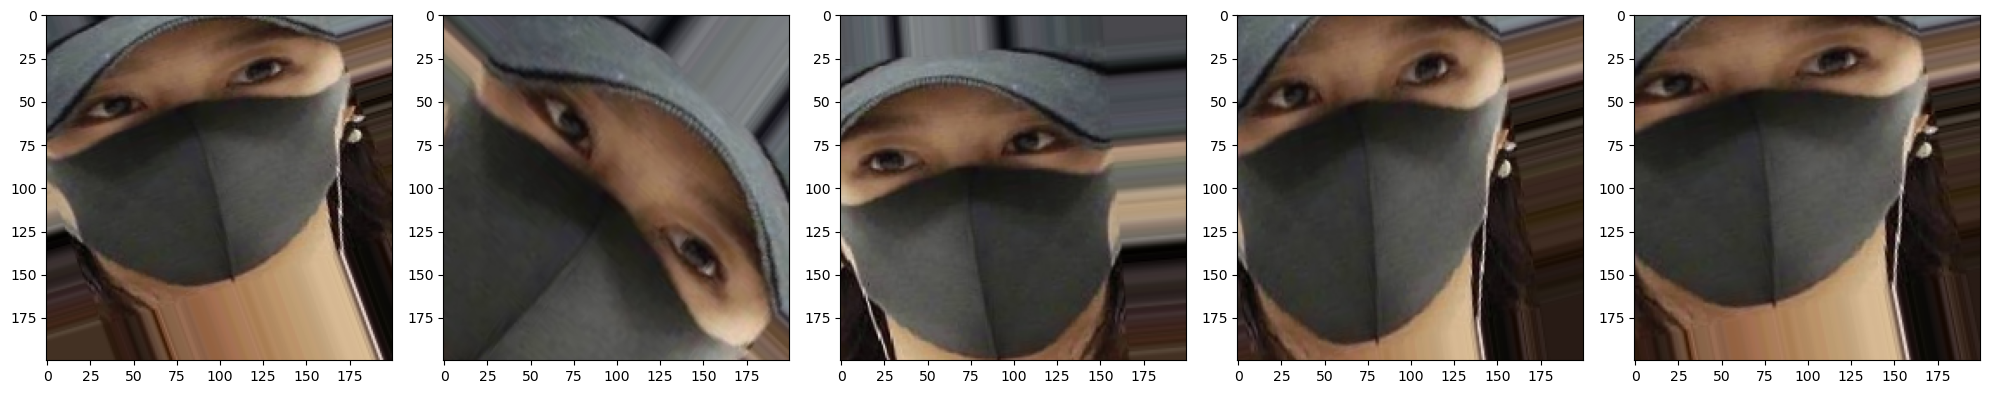

In [7]:
# Augmented images dikhao
images = [training_data[0][0][0] for i in range(5)]
plotImages(images)

In [8]:
from tensorflow.keras.callbacks import ModelCheckpoint

model_path = 'model/model.h5'
checkpoint = ModelCheckpoint(
    model_path,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max'
)
callbacks_list = [checkpoint]

In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam

# CNN Model
cnn_model = keras.models.Sequential([
    keras.layers.Conv2D(filters=32, kernel_size=5, activation='relu', input_shape=[200, 200, 3]),
    keras.layers.MaxPooling2D(pool_size=(4, 4)),

    keras.layers.Conv2D(filters=64, kernel_size=4, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=256, kernel_size=2, activation='relu'),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Dropout(0.5),
    keras.layers.Flatten(),
    keras.layers.Dense(units=128, activation='relu'),
    keras.layers.Dropout(0.1),
    keras.layers.Dense(units=256, activation='relu'),
    keras.layers.Dropout(0.25),
    keras.layers.Dense(units=2, activation='softmax')  # 2 classes: mask / no mask
])

cnn_model.summary()

c:\Users\great\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 196, 196, 32)   │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 46, 46, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 13, 13, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 256)      │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 405,186 (1.55 MB)

 Trainable params: 405,186 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
# class_mode='categorical' hai toh loss bhi 'categorical_crossentropy' hogi
cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

In [11]:
# Model train karo
history = cnn_model.fit(
    training_data,
    epochs=50,
    verbose=1,
    validation_data=valid_data,
    callbacks=callbacks_list
)

Epoch 1/50
2/8 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.6136 - loss: 0.6545

c:\Users\great\anaconda3\Lib\site-packages\PIL\Image.py:1039: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8988 - loss: 0.3694
Epoch 1: val_accuracy improved from None to 0.57692, saving model to model/model.h5



Epoch 1: finished saving model to model/model.h5
8/8 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.9967 - loss: 0.1527 - val_accuracy: 0.5769 - val_loss: 26.3807
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 2: val_accuracy did not improve from 0.57692
8/8 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5769 - val_loss: 147.5722
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3: val_accuracy did not improve from 0.57692
8/8 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5769 - val_loss: 284.0004
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 4: val_accuracy did not improve from 0.57692
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 0.5769 - val_loss: 379.0245
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 1.0000 - los

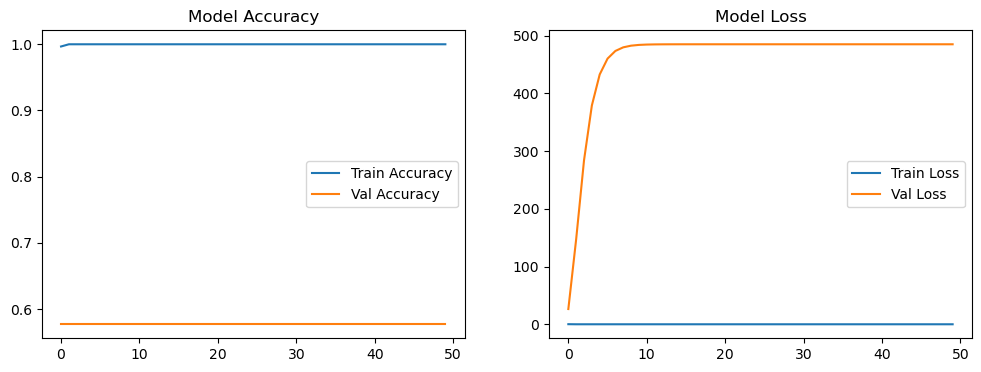

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [13]:
cnn_model.save('models/model_last.h5')
print("Model saved!")

Model saved!


In [14]:
import cv2
import numpy as np
from keras.models import load_model
from keras.preprocessing.image import load_img, img_to_array
import os

model = load_model('model/model.h5')

img_width, img_height = 200, 200


haarcascade_path = r"C:\Deep_Learning\Mask Detection - CNN\haarcascade_frontalface_default (1).xml"
face_cascade = cv2.CascadeClassifier(haarcascade_path)

print("Model aur Cascade loaded!")

Model aur Cascade loaded!


In [ ]:
# Webcam Detection
cap = cv2.VideoCapture(0) 

font = cv2.FONT_HERSHEY_SIMPLEX
fontScale = 1
thickness = 2
img_count_full = 0

while True:
    img_count_full += 1

    response, color_img = cap.read()

    if not response:
        print("Webcam se image nahi mili, band ho raha hai...")
        break

    gray_img = cv2.cvtColor(color_img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_img, 1.1, 6)

   
    img_count = 0
    for (x, y, w, h) in faces:
        img_count += 1
        org = (x - 10, max(y - 10, 0))  # text position

        color_face = color_img[y:y+h, x:x+w]

        face_path = f'faces/temp_face_{img_count_full}_{img_count}.jpg'
        cv2.imwrite(face_path, color_face)

        img = load_img(face_path, target_size=(img_width, img_height))
        img_array = img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        pred_prob = model.predict(img_array, verbose=0)
        pred = np.argmax(pred_prob)

        if pred == 0:
            class_label = "Mask"
            box_color = (0, 255, 0)   # mask
            text_color = (0, 255, 0)
            cv2.imwrite(f'faces/with_mask/{img_count_full}_{img_count}.jpg', color_face)
        else:
            class_label = "No Mask"
            box_color = (0, 0, 255)   # no mask
            text_color = (0, 0, 255)
            cv2.imwrite(f'faces/without_mask/{img_count_full}_{img_count}.jpg', color_face)

        cv2.rectangle(color_img, (x, y), (x+w, y+h), box_color, 3)
        cv2.putText(color_img, class_label, org, font, fontScale, text_color, thickness, cv2.LINE_AA)

    cv2.imshow('LIVE Face Mask Detection - Q dabao band karne ke liye', color_img)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()
print("Detection band ho gaya.")

Detection band ho gaya.
